---
# Development Notebook for PBC 3.0

### This notebook is for testing and developing the PBC 3.0 algorithm.
---

In [17]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import time

RESAMPLE = {
    "nearest": Image.Resampling.NEAREST,
    "box": Image.Resampling.BOX,
    "bilinear": Image.Resampling.BILINEAR,
    "hamming": Image.Resampling.HAMMING,
    "bicubic": Image.Resampling.BICUBIC,
    "lanczos": Image.Resampling.LANCZOS,
}

Original size: (320, 320)


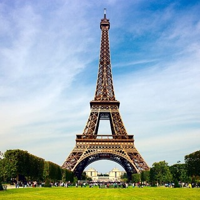

In [3]:
img = Image.open("test_images/eiffel2.jpg")
print(f"Original size: {img.size}")
img.resize((200,200))

In [47]:
def delta_matrix(img1, img2):
    return np.array(img1, dtype=np.int16) - np.array(img2, dtype=np.int16)

---
# General Image/Matrix Compression Algorithm Ideas
---

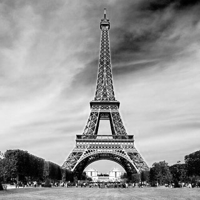

In [8]:
test = np.array(img.resize((200, 200)))[:, :, 0]
Image.fromarray(test)

### Quantize matrix (7 bits instead of 8 bits for example)

In [ ]:
def quantize_matrix()

---
# Downsample Init Layer Function

Initialize the image with a downsampled layer instead of a clean single color layer. This helps the model converge faster. We can compress the downsampled layer further internally with standard matrix/image compression techniques later.

---

In [77]:
def resample_image(image, nh, nw, alg=Image.BICUBIC):
    new_size = (int(nw), int(nh))
    if isinstance(image, np.ndarray):
        return Image.fromarray(image).resize(new_size, resample=alg)
    elif isinstance(image, Image.Image):
        return image.resize(new_size, resample=alg)
    elif isinstance(image, str):
        return Image.open(image).resize(new_size, resample=alg)
    else:
        raise ValueError("Unsupported image type")

def downsample_layer(image, factor, down_alg=Image.BICUBIC, up_alg=Image.BICUBIC):
    if isinstance(image, str):
        image = Image.open(image)
    elif isinstance(image, np.ndarray):
        image = Image.fromarray(image)
    elif not isinstance(image, Image.Image):
        raise ValueError("Unsupported image type")
    down_size = (int(image.size[0] / factor), int(image.size[1] / factor))
    downsampled = resample_image(image, down_size[1], down_size[0], alg=down_alg)
    return resample_image(downsampled, image.size[1], image.size[0], alg=up_alg)

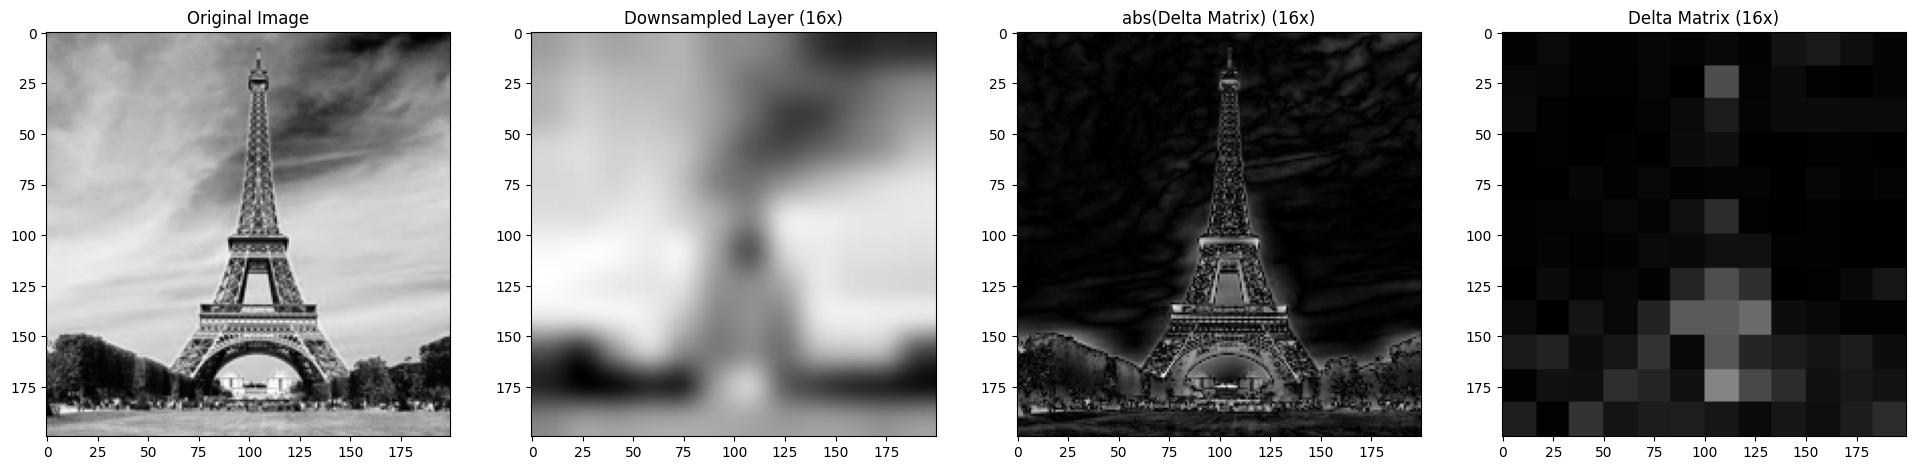

In [103]:
factor = 16
delta_factor = 16

plt.figure(figsize=(24, 6))
plt.subplot(1, 4, 1)
plt.imshow(test, cmap="gray")
plt.title("Original Image")
plt.subplot(1, 4, 2)
plt.imshow(downsample_layer(Image.fromarray(test), factor, RESAMPLE["bicubic"], RESAMPLE["bicubic"]), cmap="gray")
plt.title(f"Downsampled Layer ({factor}x)")
plt.subplot(1, 4, 3)
abs_delta = np.abs(delta_matrix(test, downsample_layer(Image.fromarray(test), factor, RESAMPLE["bicubic"], RESAMPLE["bicubic"])))
plt.imshow(abs_delta, cmap="gray")
plt.title(f"abs(Delta Matrix) ({factor}x)")
plt.subplot(1, 4, 4)
downsampled_abs_delta = downsample_layer(abs_delta, delta_factor, RESAMPLE["nearest"], RESAMPLE["nearest"])
plt.imshow(downsampled_abs_delta, cmap="gray")
plt.title(f"Delta Matrix ({delta_factor}x)")
plt.show()

In [166]:
def quantize_image(image, allowed_values):
    # Reconstruct the image using only the allowed values, picking the closest one for each pixel
    if isinstance(image, str):
        image = Image.open(image)
    elif isinstance(image, np.ndarray):
        image = Image.fromarray(image)
    elif not isinstance(image, Image.Image):
        raise ValueError("Unsupported image type")
    img_array = np.array(image)
    quantized_array = np.zeros_like(img_array)
    for val in allowed_values:
        mask = np.abs(img_array - val) < np.abs(quantized_array - val)
        quantized_array[mask] = val
    return Image.fromarray(quantized_array)

def quantize_image_bitcount(image, bitcount):
    if bitcount <= 0 or bitcount > 8:
        raise ValueError("Bitcount must be between 1 and 8")
    levels = 2 ** bitcount
    step = 256 // levels
    allowed_values = [i * step for i in range(levels)]
    return quantize_image(image, allowed_values)

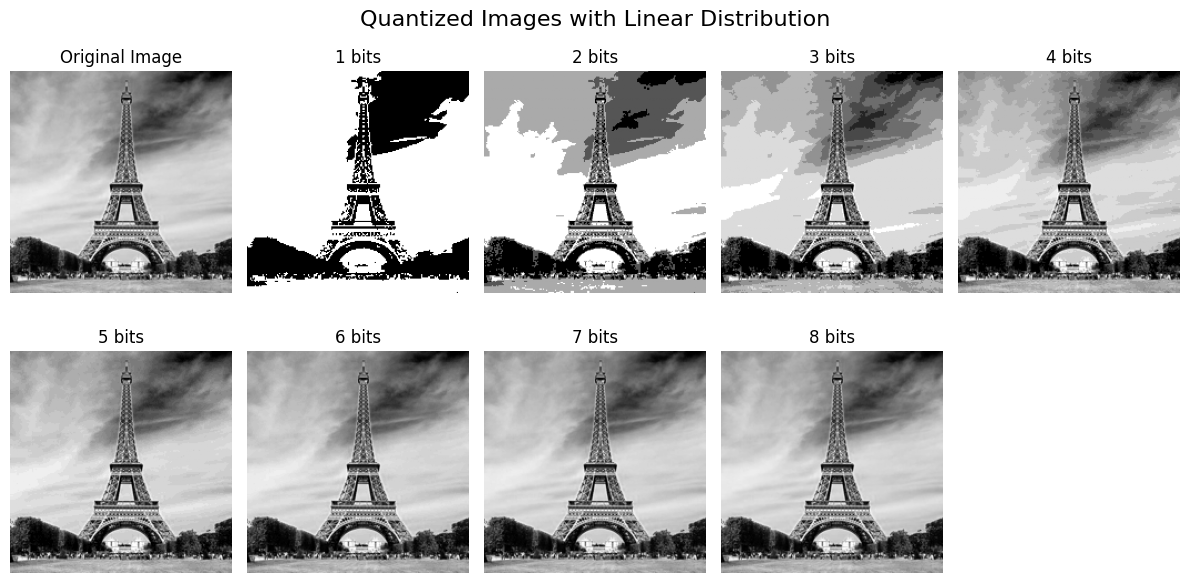

In [167]:
quantized_imgs = [quantize_image_bitcount(test, i) for i in range(1, 9)]
plt.figure(figsize=(12, 6))
plt.subplot(2, 5, 1)
plt.imshow(test, cmap="gray")
plt.axis("off")
plt.title("Original Image")
for i in range(8):
    plt.subplot(2, 5, i + 2)
    plt.imshow(quantized_imgs[i], cmap="gray")
    plt.title(f"{i+1} bits")
    plt.axis("off")
plt.tight_layout()
plt.suptitle("Quantized Images with Linear Distribution", fontsize=16, y=1.02)
plt.show()

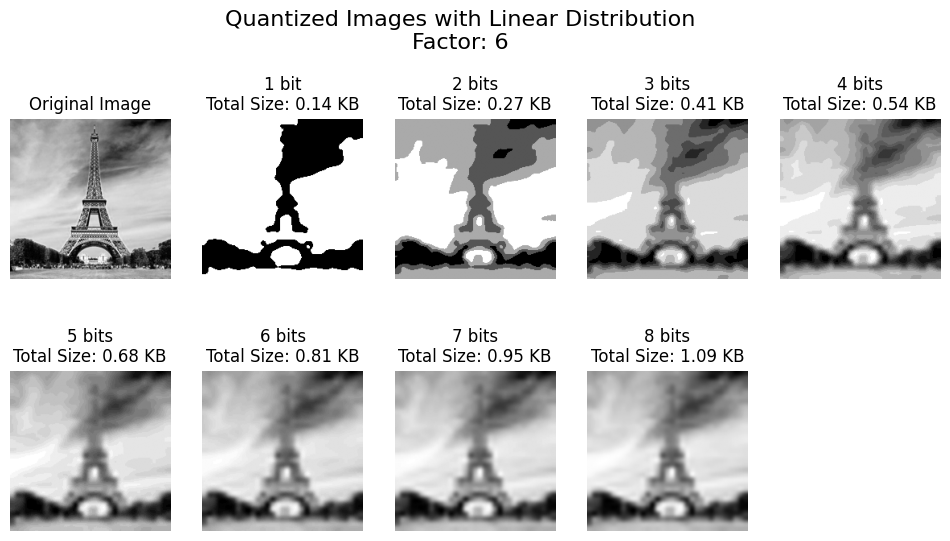

In [189]:
factor = 6

n_pixels = (test.shape[0] * test.shape[1]) / (factor ** 2)
quantized_imgs = [quantize_image_bitcount(downsample_layer(test, factor), i) for i in range(1, 9)]
plt.figure(figsize=(12, 6))
plt.subplot(2, 5, 1)
plt.imshow(test, cmap="gray")
plt.axis("off")
plt.title("Original Image")
for i in range(8):
    plt.subplot(2, 5, i + 2)
    plt.imshow(quantized_imgs[i], cmap="gray")
    plt.title(f"{i+1} bit{'s' if i != 0 else ''}\nTotal Size: {n_pixels * (i+1) / 8 / 1024:.2f} KB")
    plt.axis("off")
plt.suptitle(f"Quantized Images with Linear Distribution\nFactor: {factor}", fontsize=16, y=1.02)
plt.show()

Text(0.5, 1.0, 'Delta Matrix (12x Downsample, 8-bit Quantization)\nTotal Size: 1.09 KB | MSE: 757.38')

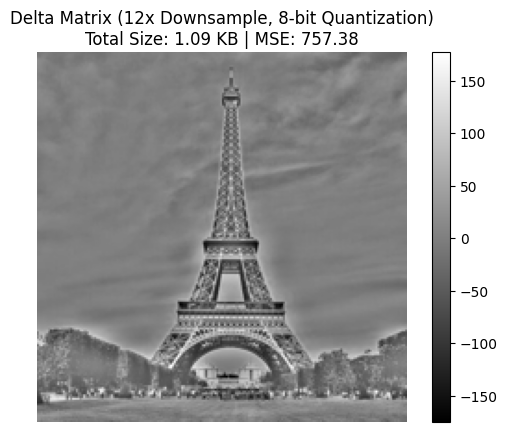

In [204]:
factor = 12
bitcount = 8
test_delta = delta_matrix(test, quantize_image_bitcount(downsample_layer(test, factor), bitcount))
plt.imshow(test_delta, cmap="gray")
plt.axis("off")
# show colorbar
plt.colorbar()
plt.title(f"Delta Matrix ({factor}x Downsample, {bitcount}-bit Quantization)\nTotal Size: {n_pixels * bitcount / 8 / 1024:.2f} KB | MSE: {np.mean(test_delta**2):.2f}")

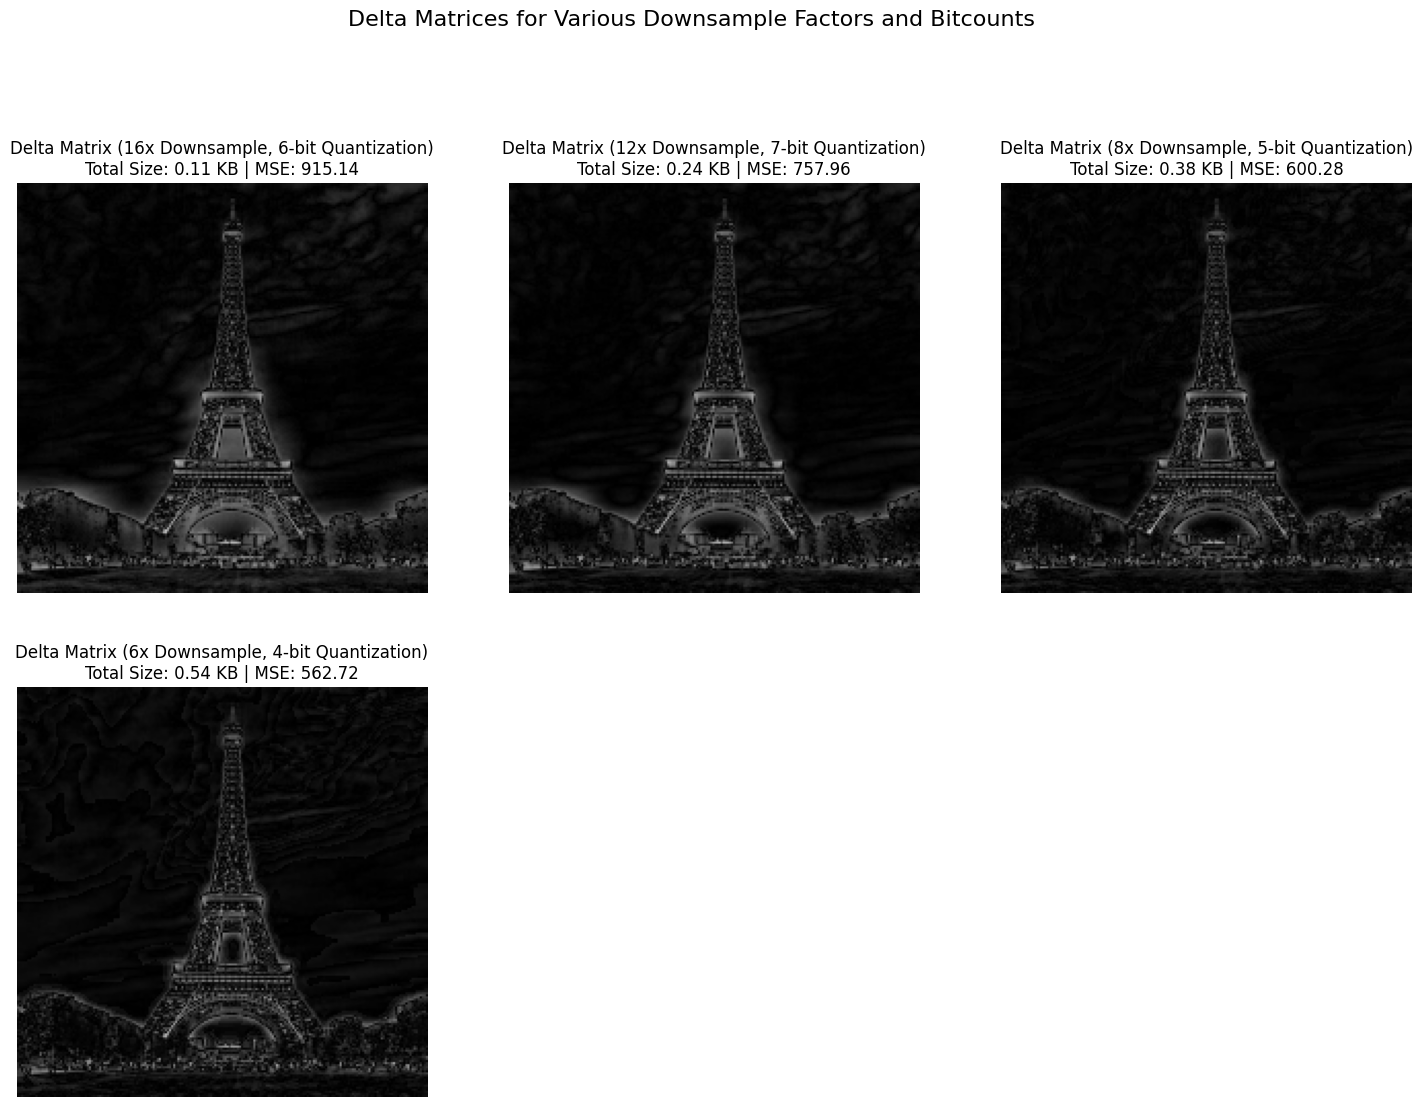

In [215]:
factor_bitcount_pairs = [(16, 6), (12, 7), (8, 5), (6, 4)]
plt.figure(figsize=(18, 12))
for idx, (factor, bitcount) in enumerate(factor_bitcount_pairs):
    test_delta = delta_matrix(test, quantize_image_bitcount(downsample_layer(test, factor), bitcount))
    plt.subplot(2, 3, idx + 1)
    plt.imshow(np.abs(test_delta), cmap="gray", vmin=0, vmax=255)
    plt.axis("off")
    n_pixels = (test.shape[0] * test.shape[1]) / (factor ** 2)
    plt.title(f"Delta Matrix ({factor}x Downsample, {bitcount}-bit Quantization)\nTotal Size: {n_pixels * bitcount / 8 / 1024:.2f} KB | MSE: {np.mean(test_delta**2):.2f}")
plt.suptitle("Delta Matrices for Various Downsample Factors and Bitcounts", fontsize=16, y=1.02)
plt.show()

---
# Patch Selector Function

Select a patch depending on the delta matrix, the difference between the source (target) image and the current canvas, this should be iterative and we can optimize the internals of the patch in the next section to capture as much info in as little space as possible. But the patch selector itself is also important, it has to be able to select a large enough section to prevent too many iterations, but also small enough that each patch can be optimized well.

Ideas:

- Convolve over the delta grid with a big kernel (ex 20x20 or maybe proportional to the image size itself so like 5% of the image dimension), select the cell with the highest error, then select a patch around that cell, expand from the cell's highest error point until the error / size rate drops below a certain threshold or until we reach a max patch size.
- Pick the single highest error point, expand from there
- Compress the final patch shape by either using the fourier windshield wiper method or by a simple bounding box and saving the shape as a set of two coordinates top left and bottom right so 4 numbers which could be represented in as little as 4 bytes with some quantization

---

---
# Patch Filler Function

Given a selected patch, a target image, and the current canvas, optimize the patch to best fit as much information as possible in the patch in as little space as possible. 

Ideas:

- Get grid fineness based on the frequency of the delta matrix in the patch, higher frequency means finer grid and more tiles, lower frequency means coarser grid and less tiles.
- Threshold for which colors are considered the same, this threshold should depend on the amount of error in the current image, if there's a ton of error, it should be a bigger threshold since the priority is to rapidly capture the general image, if there's only a little error left, it should be smaller because now the priority is to capture the finer details.
- Look at all the values in the delta matrix in the patch, find most common values, generate multlist for those values so each grid tile can have less bits. For example if the patch only has 3 types of colors (within threshold) then we can represent the patch grid with 2 bits per tile instead of 8 bits while still capturing all the important information.

---